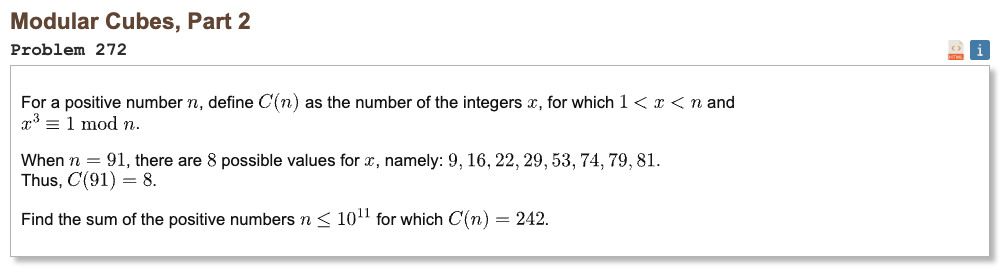

## Initial approach

* the total number of cube roots of 1 modulo n is multiplicative across prime powers
* for a prime power p^a, you get 3 roots when p ≡ 1 mod 3, and also for 3^a with a ≥ 2
* for all other prime powers, including p ≡ 2 mod 3 and a single factor of 3, you only get the trivial root 1
* since C(n) excludes x = 1, the condition C(n) = 242 means the full number of roots must be 243, which is 3^5
* so n must have exactly 5 contributing prime-power blocks, coming from primes 1 mod 3 and possibly 3^a with a ≥ 2
* any extra factors built only from primes 2 mod 3, plus maybe one extra factor 3 when 3 is not already a contributor, do not change the count
* the search becomes much smaller if you first generate all valid contributor parts, then multiply them by allowed neutral parts up to the remaining limit

In [1]:
from bisect import bisect_right

LIMIT = 10**11

def sieve(n):
    is_prime = bytearray(b"\x01") * (n + 1)
    is_prime[0:2] = b"\x00\x00"
    m = int(n**0.5)
    for i in range(2, m + 1):
        if is_prime[i]:
            start = i * i
            step = i
            is_prime[start:n + 1:step] = b"\x00" * (((n - start) // step) + 1)
    return [i for i in range(2, n + 1) if is_prime[i]]

special_limit = LIMIT // (7 * 13 * 19 * 31)
special_primes = [p for p in sieve(special_limit) if p % 3 == 1]

neutral_limit = LIMIT // (9 * 7 * 13 * 19 * 31)
neutral_primes = [p for p in sieve(neutral_limit) if p % 3 == 2]

def generate_neutral_numbers(primes, limit):
    values = []

    def dfs(index, current):
        values.append(current)
        for i in range(index, len(primes)):
            p = primes[i]
            if current * p > limit:
                break
            x = current * p
            while x <= limit:
                dfs(i + 1, x)
                x *= p

    dfs(0, 1)
    values.sort()
    return values

neutral_no3 = generate_neutral_numbers(neutral_primes, neutral_limit)

prefix_no3 = [0]
s = 0
for x in neutral_no3:
    s += x
    prefix_no3.append(s)

neutral_with3 = sorted(neutral_no3 + [3 * x for x in neutral_no3 if 3 * x <= neutral_limit])

prefix_with3 = [0]
s = 0
for x in neutral_with3:
    s += x
    prefix_with3.append(s)

def sum_neutral_no3(limit):
    return prefix_no3[bisect_right(neutral_no3, limit)]

def sum_neutral_with3(limit):
    return prefix_with3[bisect_right(neutral_with3, limit)]

def min_product(start, count):
    if start + count > len(special_primes):
        return LIMIT + 1
    result = 1
    for i in range(count):
        result *= special_primes[start + i]
    return result

result = 0

def dfs_special(start, remaining, current, three_used):
    global result

    if remaining == 0:
        rest = LIMIT // current
        if three_used:
            result += current * sum_neutral_no3(rest)
        else:
            result += current * sum_neutral_with3(rest)
        return

    if current * min_product(start, remaining) > LIMIT:
        return

    for i in range(start, len(special_primes)):
        p = special_primes[i]
        tail_min = min_product(i + 1, remaining - 1)
        if current * p * tail_min > LIMIT:
            break
        x = current * p
        while x * tail_min <= LIMIT:
            dfs_special(i + 1, remaining - 1, x, three_used)
            x *= p

dfs_special(0, 5, 1, False)

x = 9
tail4 = min_product(0, 4)
while x * tail4 <= LIMIT:
    dfs_special(0, 4, x, True)
    x *= 3

print("Result:", result)

Result: 8465125065707927588
